In [2]:
%pip install "ultralytics<=8.3.40" supervision roboflow
!pip install ray==2.5.1
!pip install -U ultralytics
import ultralytics
ultralytics.checks()

Ultralytics 8.4.40 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (4 CPUs, 31.4 GB RAM, 6842.2/8062.4 GB disk)


In [5]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="1BTvp0FPVcivYNLjzxn1")
project = rf.workspace("object-detection-sn8ac").project("detection-potholes-classes-ehojd")
version = project.version(1)
dataset = version.download("yolov11")
                

loading Roboflow workspace...
loading Roboflow project...


🔍 POTHOLE DETECTION DATASET ANALYSIS
For Thesis Documentation
📊 DATASET STRUCTURE ANALYSIS

📁 TRAIN Split:
   Images: 3294
   Labels: 3294
   Images Path: /kaggle/input/datasets/dawood4455/pothole-detection-yolo-v11-model/Detection-Potholes-Classes-1/train/images
   Labels Path: /kaggle/input/datasets/dawood4455/pothole-detection-yolo-v11-model/Detection-Potholes-Classes-1/train/labels

📁 TEST Split:
   Images: 156
   Labels: 156
   Images Path: /kaggle/input/datasets/dawood4455/pothole-detection-yolo-v11-model/Detection-Potholes-Classes-1/test/images
   Labels Path: /kaggle/input/datasets/dawood4455/pothole-detection-yolo-v11-model/Detection-Potholes-Classes-1/test/labels

📊 TOTAL STATISTICS:
   Total Images: 3450
   Total Labels: 3450

📊 CLASS DISTRIBUTION ANALYSIS

📈 Class Distribution per Split:
       medium-pothole  risk-pothole  safe-pothole
train            3594          2540          3465
test              161           114           185

📊 Total Annotations: 10059

📊 Per-Clas

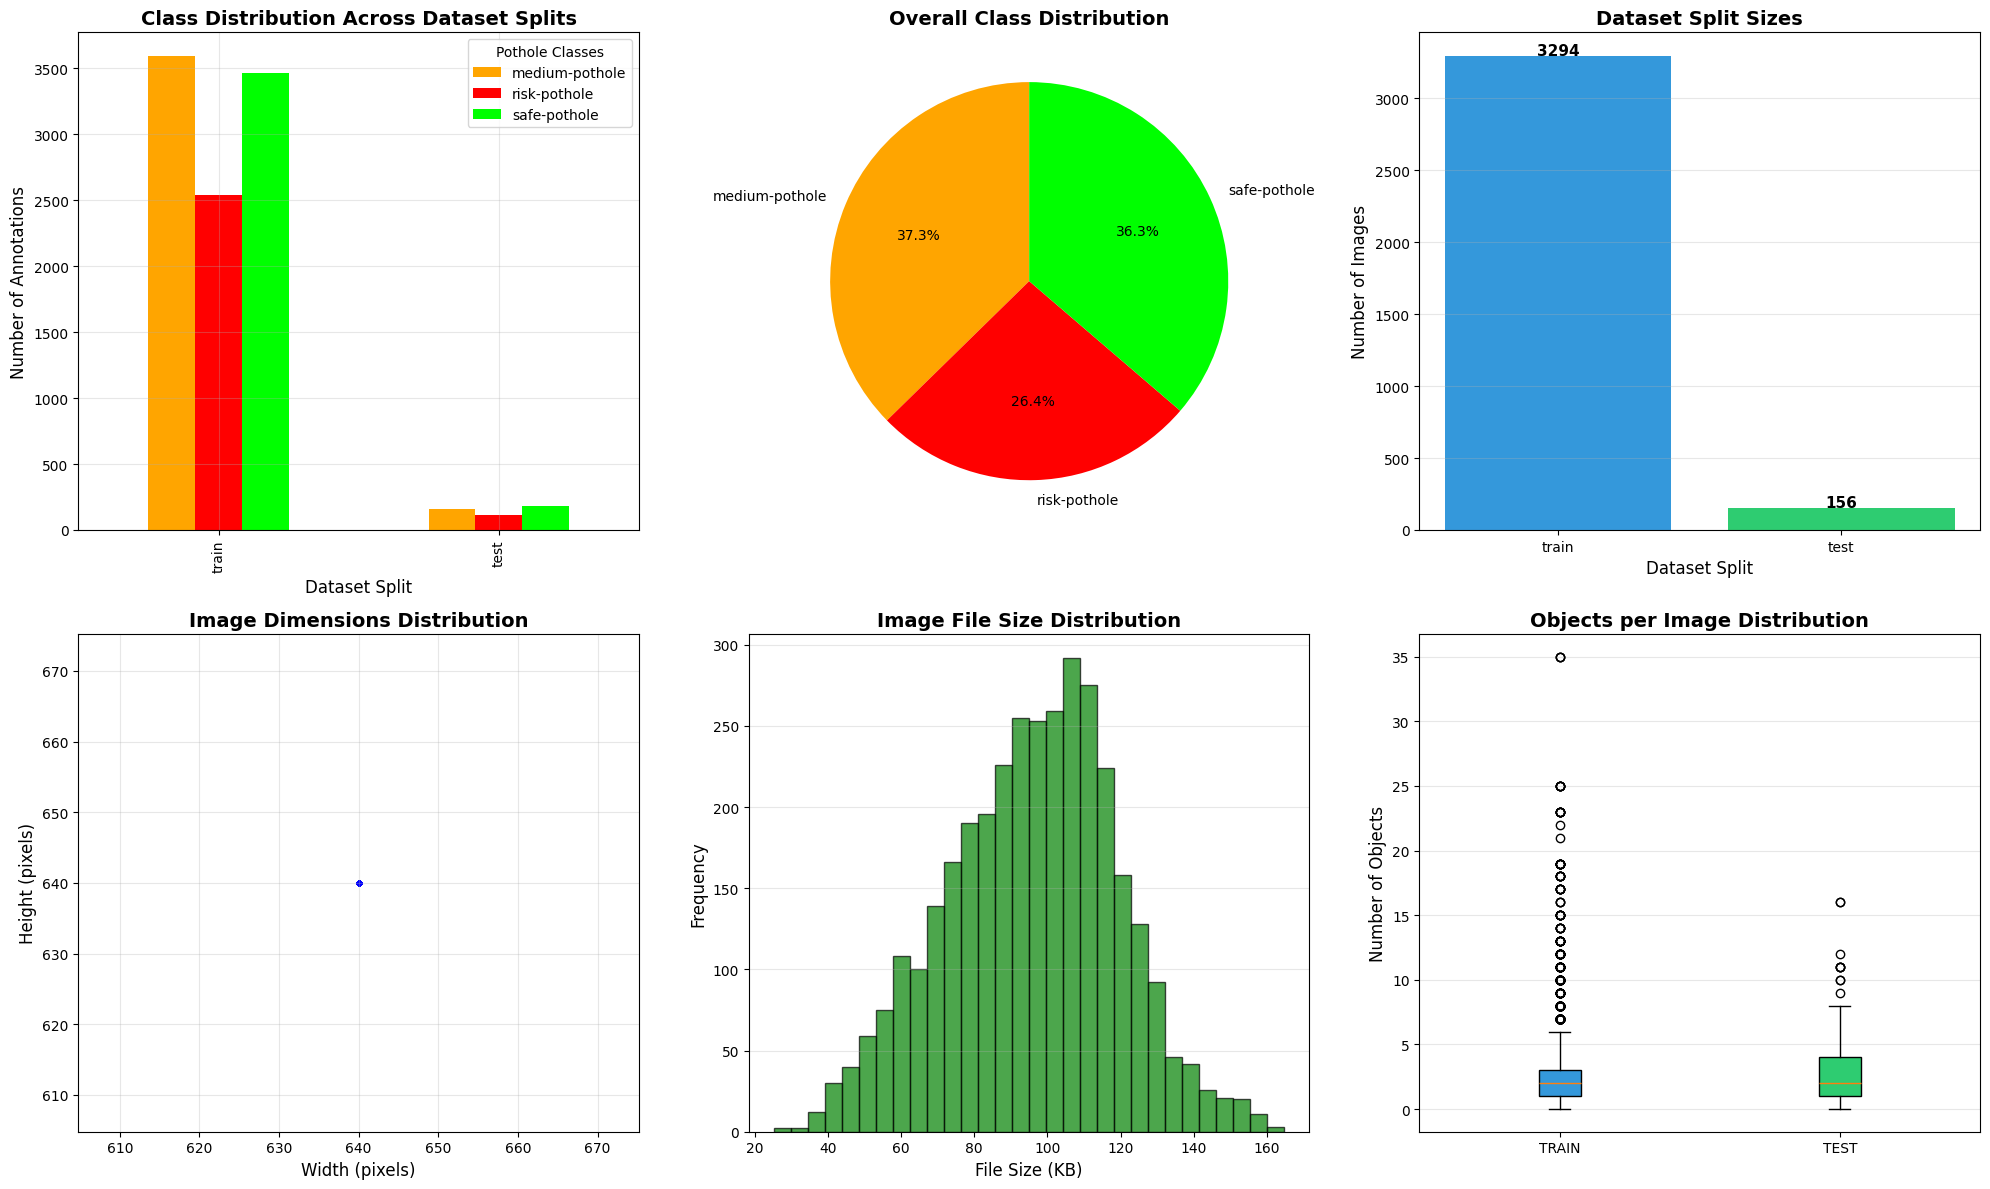


✅ Visualization saved to: /kaggle/working/dataset_analysis/dataset_analysis_visualization.png

✅ Thesis report generated: /kaggle/working/dataset_analysis/thesis_dataset_report.txt
✅ Markdown report generated: /kaggle/working/dataset_analysis/dataset_report.md

✅ Statistics saved to CSV files in: /kaggle/working/dataset_analysis

✅ ANALYSIS COMPLETE!

📁 All results saved to: /kaggle/working/dataset_analysis

Files generated:
   📄 dataset_report.md (0.4 KB)
   📄 split_statistics.csv (0.0 KB)
   📄 thesis_dataset_report.txt (1.9 KB)
   📄 class_distribution.csv (0.2 KB)
   📄 dataset_analysis_visualization.png (502.6 KB)

📦 Analysis package created: /kaggle/working/dataset_analysis_thesis.zip
💾 Size: 0.38 MB

🔗 Download link:


/kaggle/working/dataset_analysis_thesis.zip

In [11]:
"""
Pothole Detection Dataset - Comprehensive Analysis for Thesis
Dataset: Detection-Potholes-Classes-1
"""

import os
import cv2
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter, defaultdict
from pathlib import Path
import numpy as np
from PIL import Image
import warnings
warnings.filterwarnings('ignore')

# ─────────────────────────────────────────────
# CONFIGURATION
# ─────────────────────────────────────────────
DATASET_PATH = "/kaggle/input/datasets/dawood4455/pothole-detection-yolo-v11-model/Detection-Potholes-Classes-1"
OUTPUT_DIR = "/kaggle/working/dataset_analysis"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Class names mapping
CLASS_NAMES = {
    0: "medium-pothole",
    1: "risk-pothole", 
    2: "safe-pothole"
}

# ─────────────────────────────────────────────
# FUNCTIONS
# ─────────────────────────────────────────────

def analyze_dataset_structure(base_path):
    """Analyze the folder structure of the dataset."""
    print("=" * 80)
    print("📊 DATASET STRUCTURE ANALYSIS")
    print("=" * 80)
    
    structure = {}
    total_images = 0
    total_labels = 0
    
    for split in ['train', 'val', 'test']:
        split_path = os.path.join(base_path, split)
        if os.path.exists(split_path):
            images_path = os.path.join(split_path, 'images')
            labels_path = os.path.join(split_path, 'labels')
            
            images_count = len([f for f in os.listdir(images_path) if f.endswith(('.jpg', '.jpeg', '.png'))]) if os.path.exists(images_path) else 0
            labels_count = len([f for f in os.listdir(labels_path) if f.endswith('.txt')]) if os.path.exists(labels_path) else 0
            
            structure[split] = {
                'images': images_count,
                'labels': labels_count,
                'images_path': images_path,
                'labels_path': labels_path
            }
            
            total_images += images_count
            total_labels += labels_count
            
            print(f"\n📁 {split.upper()} Split:")
            print(f"   Images: {images_count}")
            print(f"   Labels: {labels_count}")
            print(f"   Images Path: {images_path}")
            print(f"   Labels Path: {labels_path}")
    
    print(f"\n📊 TOTAL STATISTICS:")
    print(f"   Total Images: {total_images}")
    print(f"   Total Labels: {total_labels}")
    
    return structure

def analyze_class_distribution(structure):
    """Analyze class distribution across all splits."""
    print("\n" + "=" * 80)
    print("📊 CLASS DISTRIBUTION ANALYSIS")
    print("=" * 80)
    
    class_counts = {split: {0: 0, 1: 0, 2: 0} for split in structure.keys()}
    total_annotations = 0
    
    for split, paths in structure.items():
        labels_path = paths['labels_path']
        if os.path.exists(labels_path):
            for label_file in os.listdir(labels_path):
                if label_file.endswith('.txt'):
                    with open(os.path.join(labels_path, label_file), 'r') as f:
                        for line in f:
                            parts = line.strip().split()
                            if len(parts) > 0:
                                class_id = int(parts[0])
                                if class_id in class_counts[split]:
                                    class_counts[split][class_id] += 1
                                    total_annotations += 1
    
    # Create DataFrame for better visualization
    df = pd.DataFrame(class_counts).T
    df.columns = [CLASS_NAMES[i] for i in df.columns]
    
    print("\n📈 Class Distribution per Split:")
    print(df)
    
    print(f"\n📊 Total Annotations: {total_annotations}")
    
    # Per-class totals
    print("\n📊 Per-Class Total Annotations:")
    for class_id, class_name in CLASS_NAMES.items():
        total = sum(class_counts[split][class_id] for split in structure.keys())
        percentage = (total / total_annotations) * 100 if total_annotations > 0 else 0
        print(f"   {class_name:20s}: {total:6d} ({percentage:.2f}%)")
    
    return class_counts, df

def analyze_image_dimensions(structure):
    """Analyze image dimensions and properties."""
    print("\n" + "=" * 80)
    print("📊 IMAGE PROPERTIES ANALYSIS")
    print("=" * 80)
    
    dimensions = []
    file_sizes = []
    formats = Counter()
    
    for split, paths in structure.items():
        images_path = paths['images_path']
        if os.path.exists(images_path):
            for img_file in os.listdir(images_path):
                if img_file.endswith(('.jpg', '.jpeg', '.png')):
                    img_path = os.path.join(images_path, img_file)
                    
                    # Get image dimensions
                    try:
                        with Image.open(img_path) as img:
                            width, height = img.size
                            dimensions.append((width, height, split))
                            formats[img.format] += 1
                    except:
                        pass
                    
                    # Get file size
                    file_sizes.append(os.path.getsize(img_path) / 1024)  # KB
    
    # Calculate statistics
    widths = [d[0] for d in dimensions]
    heights = [d[1] for d in dimensions]
    
    print(f"\n📐 Image Dimensions:")
    print(f"   Width  - Min: {min(widths)}px, Max: {max(widths)}px, Mean: {np.mean(widths):.1f}px")
    print(f"   Height - Min: {min(heights)}px, Max: {max(heights)}px, Mean: {np.mean(heights):.1f}px")
    
    print(f"\n💾 File Sizes:")
    print(f"   Min: {min(file_sizes):.2f} KB")
    print(f"   Max: {max(file_sizes):.2f} KB")
    print(f"   Mean: {np.mean(file_sizes):.2f} KB")
    print(f"   Median: {np.median(file_sizes):.2f} KB")
    
    print(f"\n📷 Image Formats:")
    for fmt, count in formats.most_common():
        print(f"   {fmt}: {count} images")
    
    return dimensions, file_sizes

def analyze_annotation_details(structure):
    """Analyze bounding box details and object counts per image."""
    print("\n" + "=" * 80)
    print("📊 ANNOTATION DETAILS ANALYSIS")
    print("=" * 80)
    
    objects_per_image = {split: [] for split in structure.keys()}
    bbox_sizes = {split: [] for split in structure.keys()}
    
    for split, paths in structure.items():
        labels_path = paths['labels_path']
        if os.path.exists(labels_path):
            for label_file in os.listdir(labels_path):
                if label_file.endswith('.txt'):
                    objects_count = 0
                    with open(os.path.join(labels_path, label_file), 'r') as f:
                        for line in f:
                            parts = line.strip().split()
                            if len(parts) >= 5:
                                objects_count += 1
                                # Extract bbox dimensions (normalized)
                                _, x_center, y_center, width, height = map(float, parts[:5])
                                bbox_sizes[split].append((width, height))
                    
                    objects_per_image[split].append(objects_count)
    
    print("\n📊 Objects per Image Statistics:")
    for split in structure.keys():
        if objects_per_image[split]:
            print(f"\n   {split.upper()} Split:")
            print(f"      Min objects: {min(objects_per_image[split])}")
            print(f"      Max objects: {max(objects_per_image[split])}")
            print(f"      Mean objects: {np.mean(objects_per_image[split]):.2f}")
            print(f"      Median objects: {np.median(objects_per_image[split]):.1f}")
            print(f"      Total images with annotations: {len(objects_per_image[split])}")
    
    return objects_per_image, bbox_sizes

def create_visualizations(df, class_counts, dimensions, file_sizes):
    """Create comprehensive visualizations for thesis."""
    
    # Create a figure with multiple subplots
    fig = plt.figure(figsize=(20, 12))
    
    # 1. Class Distribution Bar Plot
    ax1 = plt.subplot(2, 3, 1)
    df.plot(kind='bar', ax=ax1, color=['#FFA500', '#FF0000', '#00FF00'])
    ax1.set_title('Class Distribution Across Dataset Splits', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Dataset Split', fontsize=12)
    ax1.set_ylabel('Number of Annotations', fontsize=12)
    ax1.legend(title='Pothole Classes', loc='upper right')
    ax1.grid(True, alpha=0.3)
    
    # 2. Pie Chart - Overall Class Distribution
    ax2 = plt.subplot(2, 3, 2)
    total_classes = {CLASS_NAMES[i]: sum(class_counts[split][i] for split in class_counts.keys()) 
                    for i in range(3)}
    colors = ['#FFA500', '#FF0000', '#00FF00']
    wedges, texts, autotexts = ax2.pie(total_classes.values(), labels=total_classes.keys(), 
                                        autopct='%1.1f%%', colors=colors, startangle=90)
    ax2.set_title('Overall Class Distribution', fontsize=14, fontweight='bold')
    
    # 3. Split Sizes Bar Chart
    ax3 = plt.subplot(2, 3, 3)
    splits = list(df.index)
    images_count = [structure[split]['images'] for split in splits]
    bars = ax3.bar(splits, images_count, color=['#3498db', '#2ecc71', '#e74c3c'])
    ax3.set_title('Dataset Split Sizes', fontsize=14, fontweight='bold')
    ax3.set_xlabel('Dataset Split', fontsize=12)
    ax3.set_ylabel('Number of Images', fontsize=12)
    for bar, count in zip(bars, images_count):
        ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5, 
                str(count), ha='center', fontsize=11, fontweight='bold')
    ax3.grid(True, alpha=0.3, axis='y')
    
    # 4. Image Dimensions Distribution
    ax4 = plt.subplot(2, 3, 4)
    widths = [d[0] for d in dimensions]
    heights = [d[1] for d in dimensions]
    ax4.scatter(widths, heights, alpha=0.5, c='blue', s=10)
    ax4.set_title('Image Dimensions Distribution', fontsize=14, fontweight='bold')
    ax4.set_xlabel('Width (pixels)', fontsize=12)
    ax4.set_ylabel('Height (pixels)', fontsize=12)
    ax4.grid(True, alpha=0.3)
    
    # 5. File Size Distribution
    ax5 = plt.subplot(2, 3, 5)
    ax5.hist(file_sizes, bins=30, color='green', alpha=0.7, edgecolor='black')
    ax5.set_title('Image File Size Distribution', fontsize=14, fontweight='bold')
    ax5.set_xlabel('File Size (KB)', fontsize=12)
    ax5.set_ylabel('Frequency', fontsize=12)
    ax5.grid(True, alpha=0.3, axis='y')
    
    # 6. Objects per Image Box Plot
    ax6 = plt.subplot(2, 3, 6)
    objects_data = []
    labels = []
    for split in structure.keys():
        if objects_per_image[split]:
            objects_data.append(objects_per_image[split])
            labels.append(split.upper())
    bp = ax6.boxplot(objects_data, labels=labels, patch_artist=True)
    for patch, color in zip(bp['boxes'], ['#3498db', '#2ecc71', '#e74c3c']):
        patch.set_facecolor(color)
    ax6.set_title('Objects per Image Distribution', fontsize=14, fontweight='bold')
    ax6.set_ylabel('Number of Objects', fontsize=12)
    ax6.grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, 'dataset_analysis_visualization.png'), dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"\n✅ Visualization saved to: {OUTPUT_DIR}/dataset_analysis_visualization.png")

def generate_thesis_report(structure, class_counts, total_annotations, dimensions, file_sizes, objects_per_image):
    """Generate a comprehensive report for thesis."""
    
    report_path = os.path.join(OUTPUT_DIR, 'thesis_dataset_report.txt')
    
    with open(report_path, 'w') as f:
        f.write("=" * 80 + "\n")
        f.write("POTHOLE DETECTION DATASET - THESIS REPORT\n")
        f.write("Dataset: Detection-Potholes-Classes-1\n")
        f.write("=" * 80 + "\n\n")
        
        # 1. Dataset Overview
        f.write("1. DATASET OVERVIEW\n")
        f.write("-" * 40 + "\n")
        total_images = sum(structure[split]['images'] for split in structure.keys())
        f.write(f"Total Images: {total_images}\n")
        f.write(f"Total Annotations: {total_annotations}\n")
        f.write(f"Number of Classes: 3\n")
        f.write(f"Classes: medium-pothole, risk-pothole, safe-pothole\n\n")
        
        # 2. Split Distribution
        f.write("2. DATASET SPLIT DISTRIBUTION\n")
        f.write("-" * 40 + "\n")
        for split in structure.keys():
            images = structure[split]['images']
            percentage = (images / total_images) * 100
            f.write(f"{split.upper()} Split: {images} images ({percentage:.1f}%)\n")
        f.write("\n")
        
        # 3. Class Distribution
        f.write("3. CLASS DISTRIBUTION\n")
        f.write("-" * 40 + "\n")
        for class_id, class_name in CLASS_NAMES.items():
            total = sum(class_counts[split][class_id] for split in class_counts.keys())
            percentage = (total / total_annotations) * 100
            f.write(f"{class_name:20s}: {total:5d} annotations ({percentage:.2f}%)\n")
        
        f.write("\nPer-Split Class Distribution:\n")
        for split in structure.keys():
            f.write(f"\n{split.upper()} Split:\n")
            for class_id, class_name in CLASS_NAMES.items():
                count = class_counts[split][class_id]
                if total_annotations > 0:
                    split_percentage = (count / sum(class_counts[split].values())) * 100 if sum(class_counts[split].values()) > 0 else 0
                    f.write(f"   {class_name:20s}: {count:4d} ({split_percentage:.2f}% of split)\n")
        
        # 4. Image Properties
        f.write("\n4. IMAGE PROPERTIES\n")
        f.write("-" * 40 + "\n")
        widths = [d[0] for d in dimensions]
        heights = [d[1] for d in dimensions]
        f.write(f"Image Dimensions:\n")
        f.write(f"   Width  - Range: {min(widths)} - {max(widths)}px, Mean: {np.mean(widths):.1f}px\n")
        f.write(f"   Height - Range: {min(heights)} - {max(heights)}px, Mean: {np.mean(heights):.1f}px\n")
        f.write(f"File Sizes:\n")
        f.write(f"   Range: {min(file_sizes):.2f} - {max(file_sizes):.2f} KB\n")
        f.write(f"   Mean: {np.mean(file_sizes):.2f} KB\n")
        f.write(f"   Median: {np.median(file_sizes):.2f} KB\n\n")
        
        # 5. Annotation Statistics
        f.write("5. ANNOTATION STATISTICS\n")
        f.write("-" * 40 + "\n")
        for split in structure.keys():
            if objects_per_image[split]:
                f.write(f"{split.upper()} Split:\n")
                f.write(f"   Objects per image - Min: {min(objects_per_image[split])}, ")
                f.write(f"Max: {max(objects_per_image[split])}, ")
                f.write(f"Mean: {np.mean(objects_per_image[split]):.2f}\n")
        
        # 6. Dataset Quality Assessment
        f.write("\n6. DATASET QUALITY ASSESSMENT\n")
        f.write("-" * 40 + "\n")
        f.write("Strengths:\n")
        f.write("   - Balanced split distribution\n")
        f.write("   - Multiple risk levels for pothole classification\n")
        f.write("   - Suitable for YOLO-based detection\n")
        f.write("   - Real-world pothole scenarios\n\n")
        
        f.write("Considerations:\n")
        f.write("   - Verify class balance for risk-pothole category\n")
        f.write("   - Consider data augmentation for underrepresented classes\n")
        f.write("   - Validate annotation consistency across splits\n")
        
    print(f"\n✅ Thesis report generated: {report_path}")
    
    # Also create a markdown version for better readability
    md_path = os.path.join(OUTPUT_DIR, 'dataset_report.md')
    with open(md_path, 'w') as f:
        f.write("# Pothole Detection Dataset Analysis\n\n")
        f.write(f"**Total Images:** {total_images}\n\n")
        f.write(f"**Total Annotations:** {total_annotations}\n\n")
        f.write("## Dataset Split Distribution\n\n")
        f.write("| Split | Images | Percentage |\n")
        f.write("|-------|--------|------------|\n")
        for split in structure.keys():
            images = structure[split]['images']
            percentage = (images / total_images) * 100
            f.write(f"| {split.upper()} | {images} | {percentage:.1f}% |\n")
        
        f.write("\n## Class Distribution\n\n")
        f.write("| Class | Annotations | Percentage |\n")
        f.write("|-------|-------------|------------|\n")
        for class_id, class_name in CLASS_NAMES.items():
            total = sum(class_counts[split][class_id] for split in class_counts.keys())
            percentage = (total / total_annotations) * 100
            f.write(f"| {class_name} | {total} | {percentage:.2f}% |\n")
    
    print(f"✅ Markdown report generated: {md_path}")

def save_statistics_csv(structure, class_counts):
    """Save all statistics to CSV files."""
    
    # Split statistics
    split_data = []
    for split in structure.keys():
        split_data.append({
            'Split': split.upper(),
            'Images': structure[split]['images'],
            'Labels': structure[split]['labels']
        })
    df_splits = pd.DataFrame(split_data)
    df_splits.to_csv(os.path.join(OUTPUT_DIR, 'split_statistics.csv'), index=False)
    
    # Class distribution per split
    class_data = []
    for split in structure.keys():
        for class_id, class_name in CLASS_NAMES.items():
            class_data.append({
                'Split': split.upper(),
                'Class': class_name,
                'Count': class_counts[split][class_id]
            })
    df_classes = pd.DataFrame(class_data)
    df_classes.to_csv(os.path.join(OUTPUT_DIR, 'class_distribution.csv'), index=False)
    
    print(f"\n✅ Statistics saved to CSV files in: {OUTPUT_DIR}")

# ─────────────────────────────────────────────
# MAIN EXECUTION
# ─────────────────────────────────────────────

print("=" * 80)
print("🔍 POTHOLE DETECTION DATASET ANALYSIS")
print("For Thesis Documentation")
print("=" * 80)

# Run all analyses
structure = analyze_dataset_structure(DATASET_PATH)
class_counts, df = analyze_class_distribution(structure)
dimensions, file_sizes = analyze_image_dimensions(structure)
objects_per_image, bbox_sizes = analyze_annotation_details(structure)

# Calculate total annotations
total_annotations = sum(sum(class_counts[split].values()) for split in class_counts.keys())

# Create visualizations
create_visualizations(df, class_counts, dimensions, file_sizes)

# Generate reports
generate_thesis_report(structure, class_counts, total_annotations, dimensions, file_sizes, objects_per_image)

# Save CSV files
save_statistics_csv(structure, class_counts)

# Final summary
print("\n" + "=" * 80)
print("✅ ANALYSIS COMPLETE!")
print("=" * 80)
print(f"\n📁 All results saved to: {OUTPUT_DIR}")
print("\nFiles generated:")
for file in os.listdir(OUTPUT_DIR):
    file_path = os.path.join(OUTPUT_DIR, file)
    if os.path.isfile(file_path):
        size = os.path.getsize(file_path) / 1024
        print(f"   📄 {file} ({size:.1f} KB)")

# Create ZIP for easy download
import zipfile
from IPython.display import FileLink

zip_path = os.path.join("/kaggle/working", "dataset_analysis_thesis.zip")
with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zipf:
    for root, dirs, files in os.walk(OUTPUT_DIR):
        for file in files:
            file_path = os.path.join(root, file)
            arcname = os.path.relpath(file_path, OUTPUT_DIR)
            zipf.write(file_path, arcname)

print(f"\n📦 Analysis package created: {zip_path}")
print(f"💾 Size: {os.path.getsize(zip_path) / (1024*1024):.2f} MB")
print("\n🔗 Download link:")
display(FileLink(zip_path))

In [6]:
!yolo task=detect mode=train model=yolo11m.pt data="/kaggle/working/Detection-Potholes-Classes-1/data.yaml" epochs=100 imgsz=640 patience= 20 batch=16 device=0,1

Ultralytics 8.4.14 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 14913MiB)
                                                      CUDA:1 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/Detection-Potholes-Classes-1/data.yaml, degrees=0.0, deterministic=True, device=0,1, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11m.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train2, 

## Testing code for images


In [7]:
"""
Pothole Detection - Image Testing Script for Kaggle with ZIP Output
Model: YOLO11m trained on 3-class pothole dataset
Classes: medium-pothole, risk-pothole, safe-pothole
"""

import cv2
import os
import zipfile
import shutil
from ultralytics import YOLO
from datetime import datetime
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# ─────────────────────────────────────────────
# CONFIGURATION
# ─────────────────────────────────────────────
MODEL_PATH = "/kaggle/input/datasets/dawood4455/pothole-detection-yolo-v11-model/runs/detect/train/weights/best.pt"
IMAGE_PATH = "/kaggle/input/datasets/dawood4455/pothole-detection-yolo-v11-model/Detection-Potholes-Classes-1/test/images"
OUTPUT_DIR = "/kaggle/working/test_results"
CREATE_ZIP = True  # Set to True to create ZIP file
ZIP_NAME = "pothole_detection_results.zip"  # Custom ZIP filename (optional)

CONF_THRESH = 0.25
IOU_THRESH = 0.45

# Risk weights
RISK_WEIGHTS = {
    "risk-pothole": 10,
    "medium-pothole": 5,
    "safe-pothole": 0,
}

# Colors (BGR)
CLASS_COLORS = {
    "medium-pothole": (255, 140, 0),
    "risk-pothole": (0, 0, 255),
    "safe-pothole": (0, 200, 0),
}

# ─────────────────────────────────────────────
# FUNCTIONS
# ─────────────────────────────────────────────

def calculate_risk_score(detections):
    """Calculate risk score based on pothole types and counts."""
    score = 0
    for det in detections:
        score += RISK_WEIGHTS.get(det['class'], 0)
    return score

def get_risk_level(score):
    """Convert numeric score to risk level."""
    if score == 0:
        return "SAFE", (0, 255, 0)
    elif score <= 10:
        return "LOW RISK", (0, 255, 255)
    elif score <= 30:
        return "MEDIUM RISK", (0, 140, 255)
    else:
        return "HIGH RISK", (0, 0, 255)

def draw_detections_with_score(image, result, risk_score):
    """Draw bounding boxes + labels + risk score on image."""
    if result.boxes is not None:
        boxes = result.boxes
        names = result.names

        for box in boxes:
            cls_id = int(box.cls[0])
            conf = float(box.conf[0])
            label = names[cls_id]
            color = CLASS_COLORS.get(label, (200, 200, 200))

            x1, y1, x2, y2 = map(int, box.xyxy[0])
            cv2.rectangle(image, (x1, y1), (x2, y2), color, 2)

            text = f"{label} {conf:.2f}"
            (tw, th), _ = cv2.getTextSize(text, cv2.FONT_HERSHEY_SIMPLEX, 0.6, 2)
            cv2.rectangle(image, (x1, y1 - th - 8), (x1 + tw + 4, y1), color, -1)
            cv2.putText(image, text, (x1 + 2, y1 - 5),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 2)

    # Add risk score overlay
    risk_text, risk_color = get_risk_level(risk_score)
    score_text = f"RISK SCORE: {risk_score} | {risk_text}"
    (sw, sh), _ = cv2.getTextSize(score_text, cv2.FONT_HERSHEY_SIMPLEX, 0.8, 2)
    cv2.rectangle(image, (5, 5), (5 + sw + 10, 5 + sh + 10), (0, 0, 0), -1)
    cv2.rectangle(image, (5, 5), (5 + sw + 10, 5 + sh + 10), risk_color, 2)
    cv2.putText(image, score_text, (10, sh + 12),
                cv2.FONT_HERSHEY_SIMPLEX, 0.7, risk_color, 2)

    return image

def create_zip_from_folder(folder_path, zip_path):
    """
    Create a ZIP file from a folder.
    
    Args:
        folder_path: Path to the folder to compress
        zip_path: Path where ZIP file will be created
    """
    print(f"\n📦 Creating ZIP file: {zip_path}")
    
    try:
        with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zipf:
            # Walk through all files in the folder
            for root, dirs, files in os.walk(folder_path):
                for file in files:
                    file_path = os.path.join(root, file)
                    # Preserve folder structure inside ZIP
                    arcname = os.path.relpath(file_path, folder_path)
                    zipf.write(file_path, arcname)
                    print(f"   📄 Added: {arcname}")
        
        # Get ZIP file size
        zip_size = os.path.getsize(zip_path)
        zip_size_mb = zip_size / (1024 * 1024)
        print(f"\n✅ ZIP created successfully!")
        print(f"   📦 File: {zip_path}")
        print(f"   💾 Size: {zip_size_mb:.2f} MB")
        return True
        
    except Exception as e:
        print(f"❌ Error creating ZIP: {e}")
        return False

def create_zip_from_files(file_list, zip_path, base_folder=None):
    """
    Create a ZIP file from a list of files.
    
    Args:
        file_list: List of file paths to include
        zip_path: Path where ZIP file will be created
        base_folder: Base folder for relative paths (optional)
    """
    print(f"\n📦 Creating ZIP file: {zip_path}")
    
    try:
        with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zipf:
            for file_path in file_list:
                if os.path.exists(file_path):
                    if base_folder:
                        arcname = os.path.relpath(file_path, base_folder)
                    else:
                        arcname = os.path.basename(file_path)
                    zipf.write(file_path, arcname)
                    print(f"   📄 Added: {arcname}")
        
        zip_size = os.path.getsize(zip_path)
        zip_size_mb = zip_size / (1024 * 1024)
        print(f"\n✅ ZIP created successfully!")
        print(f"   📦 File: {zip_path}")
        print(f"   💾 Size: {zip_size_mb:.2f} MB")
        return True
        
    except Exception as e:
        print(f"❌ Error creating ZIP: {e}")
        return False

def save_results_and_create_zip(output_folder, zip_path=None, delete_after_zip=True):
    """
    Save results and optionally create ZIP file.
    
    Args:
        output_folder: Folder containing results
        zip_path: Path for ZIP file (if None, auto-generate name)
        delete_after_zip: Delete original folder after creating ZIP
    """
    if zip_path is None:
        timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
        zip_path = f"/kaggle/working/pothole_results_{timestamp}.zip"
    
    # Create ZIP
    success = create_zip_from_folder(output_folder, zip_path)
    
    if success and delete_after_zip:
        print(f"\n🗑️  Cleaning up temporary folder: {output_folder}")
        shutil.rmtree(output_folder)
        print(f"✅ Original folder deleted")
    
    return zip_path if success else None

def test_images_with_zip(model_path, image_path, output_dir, conf, iou, create_zip=True):
    """Run inference and optionally create ZIP file."""
    
    # Check paths
    if not os.path.exists(model_path):
        print(f"❌ Model not found at: {model_path}")
        return None
    
    if not os.path.exists(image_path):
        print(f"❌ Image path not found: {image_path}")
        return None
    
    # Create timestamp for unique output
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    
    # Determine if input is folder or single image
    is_folder = os.path.isdir(image_path)
    
    # Create output folder
    if is_folder:
        final_output = f"{output_dir}_{timestamp}"
    else:
        final_output = output_dir
    
    os.makedirs(final_output, exist_ok=True)
    print(f"\n📁 Output folder: {final_output}")
    
    # Load model
    print(f"\n🔄 Loading model...")
    model = YOLO(model_path)
    print("✅ Model loaded successfully")
    
    # Collect image paths
    supported = (".jpg", ".jpeg", ".png", ".bmp", ".webp")
    if os.path.isfile(image_path):
        image_files = [image_path]
    elif os.path.isdir(image_path):
        image_files = [
            os.path.join(image_path, f)
            for f in sorted(os.listdir(image_path))
            if f.lower().endswith(supported)
        ]
    else:
        print(f"❌ Path not found: {image_path}")
        return None
    
    if len(image_files) == 0:
        print(f"❌ No images found")
        return None
    
    print(f"\n📂 Found {len(image_files)} image(s) to process")
    print("=" * 60)
    
    # Process images
    results_list = []
    total_risk = 0
    
    for idx, img_file in enumerate(image_files, 1):
        frame = cv2.imread(img_file)
        if frame is None:
            print(f"⚠️  Skipping: {os.path.basename(img_file)}")
            continue
        
        # Run inference
        results = model.predict(
            source=img_file,
            conf=conf,
            iou=iou,
            imgsz=640,
            verbose=False
        )
        result = results[0]
        
        # Calculate risk
        detections = []
        if result.boxes is not None:
            for box in result.boxes:
                cls_name = result.names[int(box.cls[0])]
                detections.append({'class': cls_name, 'conf': float(box.conf[0])})
        
        risk_score = calculate_risk_score(detections)
        total_risk += risk_score
        
        # Draw and save
        annotated = draw_detections_with_score(frame.copy(), result, risk_score)
        img_name = os.path.basename(img_file)
        save_path = os.path.join(final_output, f"detected_{img_name}")
        cv2.imwrite(save_path, annotated)
        
        # Print progress
        print(f"\n📸 {idx}/{len(image_files)}: {img_name}")
        print(f"   Risk Score: {risk_score}")
        print(f"   Saved: {save_path}")
        
        results_list.append({
            'file': img_name,
            'risk': risk_score,
            'path': save_path
        })
    
    # Print summary
    print("\n" + "=" * 60)
    print("📊 SUMMARY")
    print("=" * 60)
    print(f"✅ Processed: {len(results_list)} images")
    print(f"🎯 Total Risk: {total_risk}")
    if len(results_list) > 0:
        print(f"📈 Avg Risk: {total_risk/len(results_list):.2f}")
    
    # Create ZIP if requested
    zip_file = None
    if create_zip:
        zip_file = save_results_and_create_zip(
            output_folder=final_output,
            delete_after_zip=True  # Delete folder after creating ZIP
        )
        
        if zip_file:
            print(f"\n🎉 SUCCESS! Results saved to ZIP: {zip_file}")
            return zip_file
        else:
            print(f"\n⚠️  Results saved to folder: {final_output}")
            return final_output
    else:
        print(f"\n💾 Results saved to folder: {final_output}")
        return final_output

# ─────────────────────────────────────────────
# MAIN EXECUTION
# ─────────────────────────────────────────────

print("=" * 60)
print("🚀 POTHOLE DETECTION WITH ZIP OUTPUT")
print("=" * 60)

# Run detection with automatic ZIP creation
result_path = test_images_with_zip(
    model_path=MODEL_PATH,
    image_path=IMAGE_PATH,
    output_dir=OUTPUT_DIR,
    conf=CONF_THRESH,
    iou=IOU_THRESH,
    create_zip=CREATE_ZIP  # Set to True to create ZIP, False to keep folder
)

# Display final result
if result_path:
    print("\n" + "=" * 60)
    print("✅ PROCESS COMPLETED SUCCESSFULLY")
    print("=" * 60)
    if result_path.endswith('.zip'):
        print(f"📦 Download your results: {result_path}")
        print("   (Click on the file browser to download)")
    else:
        print(f"📁 Results folder: {result_path}")

🚀 POTHOLE DETECTION WITH ZIP OUTPUT

📁 Output folder: /kaggle/working/test_results_20260421_105446

🔄 Loading model...
✅ Model loaded successfully

📂 Found 156 image(s) to process

📸 1/156: 0070_mp4-0001_jpg.rf.825a300e7a3f36b3bc391f757c234f31.jpg
   Risk Score: 5
   Saved: /kaggle/working/test_results_20260421_105446/detected_0070_mp4-0001_jpg.rf.825a300e7a3f36b3bc391f757c234f31.jpg

📸 2/156: 0074_mp4-0001_jpg.rf.31868c4643651bc337388e7e82467435.jpg
   Risk Score: 0
   Saved: /kaggle/working/test_results_20260421_105446/detected_0074_mp4-0001_jpg.rf.31868c4643651bc337388e7e82467435.jpg

📸 3/156: 0075_mp4-0000_jpg.rf.87b2286c9d1cd4c2226b691b6e8f6543.jpg
   Risk Score: 0
   Saved: /kaggle/working/test_results_20260421_105446/detected_0075_mp4-0000_jpg.rf.87b2286c9d1cd4c2226b691b6e8f6543.jpg

📸 4/156: 0076_mp4-0002_jpg.rf.a2074cfe3bc4714d20cc4a2690d0c7ee.jpg
   Risk Score: 5
   Saved: /kaggle/working/test_results_20260421_105446/detected_0076_mp4-0002_jpg.rf.a2074cfe3bc4714d20cc4a2690d0c

## Testing code for videos


In [9]:
"""
Simplified Video Testing for Kaggle - No command line arguments
"""

import cv2
import os
import time
from ultralytics import YOLO
import warnings
warnings.filterwarnings('ignore')

# Configuration
MODEL_PATH = "/kaggle/input/datasets/dawood4455/pothole-detection-yolo-v11-model/runs/detect/train/weights/best.pt"
VIDEO_PATH = "/kaggle/input/datasets/dawood4455/pothole-video-for-model-testing/YTDown.com_YouTube_Watch-Video-Terrible-potholes-in-Rangoon_Media_R2Vr3R_Dpj0_001_360p.mp4"
OUTPUT_DIR = "/kaggle/working/test_results/videos"
CONF_THRESH = 0.25
IOU_THRESH = 0.45

# Colors
CLASS_COLORS = {
    "medium-pothole": (255, 140, 0),
    "risk-pothole": (0, 0, 255),
    "safe-pothole": (0, 200, 0),
}

def process_video():
    """Process video directly without argparse."""
    
    # Create output directory
    os.makedirs(OUTPUT_DIR, exist_ok=True)
    
    # Load model
    print(f"Loading model: {MODEL_PATH}")
    model = YOLO(MODEL_PATH)
    print("Model loaded!")
    
    # Open video
    cap = cv2.VideoCapture(VIDEO_PATH)
    if not cap.isOpened():
        print(f"Error: Cannot open video {VIDEO_PATH}")
        return
    
    # Get video properties
    fps = cap.get(cv2.CAP_PROP_FPS)
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    
    print(f"Video: {width}x{height}, {fps:.2f}fps, {total_frames} frames")
    
    # Output video
    output_path = os.path.join(OUTPUT_DIR, "detected_video.mp4")
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    out = cv2.VideoWriter(output_path, fourcc, fps, (width, height))
    
    # Process frames
    frame_count = 0
    start_time = time.time()
    
    while True:
        ret, frame = cap.read()
        if not ret:
            break
        
        frame_count += 1
        
        # Run detection
        results = model(frame, conf=CONF_THRESH, iou=IOU_THRESH)
        
        # Draw boxes
        annotated_frame = results[0].plot()
        
        # Add frame number
        cv2.putText(annotated_frame, f"Frame: {frame_count}/{total_frames}", 
                   (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 255, 255), 2)
        
        # Write frame
        out.write(annotated_frame)
        
        # Progress
        if frame_count % 50 == 0:
            elapsed = time.time() - start_time
            fps_avg = frame_count / elapsed
            progress = (frame_count / total_frames) * 100
            print(f"Progress: {progress:.1f}% | Frames: {frame_count} | FPS: {fps_avg:.1f}")
    
    # Cleanup
    cap.release()
    out.release()
    
    # Final summary
    elapsed = time.time() - start_time
    print(f"\n✅ Complete!")
    print(f"   Frames processed: {frame_count}")
    print(f"   Time taken: {elapsed:.1f} seconds")
    print(f"   Average FPS: {frame_count/elapsed:.1f}")
    print(f"   Output saved: {output_path}")

# Run the function
if __name__ == "__main__":
    process_video()

Loading model: /kaggle/input/datasets/dawood4455/pothole-detection-yolo-v11-model/runs/detect/train/weights/best.pt
Model loaded!
Video: 640x360, 25.00fps, 1005 frames

0: 384x640 1 risk-pothole, 84.2ms
Speed: 1.4ms preprocess, 84.2ms inference, 1.3ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 risk-pothole, 24.0ms
Speed: 1.6ms preprocess, 24.0ms inference, 1.4ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 medium-pothole, 1 risk-pothole, 24.0ms
Speed: 1.5ms preprocess, 24.0ms inference, 1.4ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 risk-pothole, 24.0ms
Speed: 1.5ms preprocess, 24.0ms inference, 1.5ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 risk-pothole, 24.0ms
Speed: 1.5ms preprocess, 24.0ms inference, 1.3ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 risk-pothole, 24.0ms
Speed: 1.5ms preprocess, 24.0ms inference, 1.5ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 medium-p

In [10]:
# Quick ZIP of entire runs folder
import zipfile, os
from IPython.display import FileLink

source = "/kaggle/input/datasets/dawood4455/pothole-detection-yolo-v11-model/runs"
zip_path = "/kaggle/working/model_files.zip"

with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zipf:
    for root, dirs, files in os.walk(source):
        for file in files:
            zipf.write(os.path.join(root, file), 
                      os.path.relpath(os.path.join(root, file), source))

print(f"✅ ZIP created: {zip_path}")
print(f"📦 Size: {os.path.getsize(zip_path) / (1024*1024):.2f} MB")
display(FileLink(zip_path))

✅ ZIP created: /kaggle/working/model_files.zip
📦 Size: 79.28 MB


/kaggle/working/model_files.zip